# Week 6 - Image Denoising using Autoencoder on MNIST

## Objective

The objective of this project is to build a Convolutional Autoencoder capable of removing noise from handwritten digit images using the MNIST dataset. The model learns compressed image representations and reconstructs clean images from noisy inputs.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Load MNIST dataset

(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


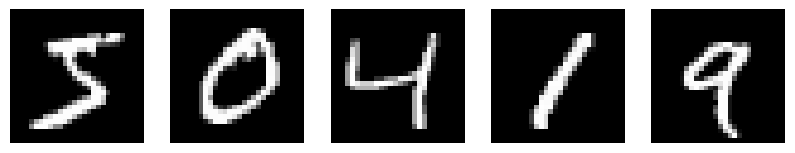

In [3]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

plt.show()

In [5]:
# Normalize pixel values

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape images to (28, 28, 1)

x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

print("Training Shape:", x_train.shape)
print("Testing Shape :", x_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


In [6]:
# Add random Gaussian noise

noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Keep pixel values between 0 and 1

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noise added successfully!")

Noise added successfully!


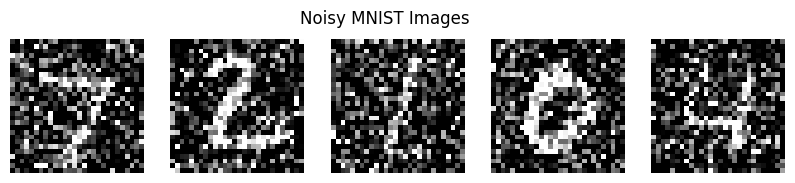

In [7]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Noisy MNIST Images")
plt.show()

In [8]:
# Encoder

input_img = Input(shape=(28, 28, 1))

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder

x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Create Model

autoencoder = Model(input_img, decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("Model compiled successfully!")

Model compiled successfully!


In [10]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 229ms/step - loss: 0.1755 - val_loss: 0.1203
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 102s 217ms/step - loss: 0.1168 - val_loss: 0.1125
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 216ms/step - loss: 0.1113 - val_loss: 0.1083
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 102s 217ms/step - loss: 0.1084 - val_loss: 0.1064
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 214ms/step - loss: 0.1064 - val_loss: 0.1046
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 103s 220ms/step - loss: 0.1048 - val_loss: 0.1035
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 226ms/step - loss: 0.1036 - val_loss: 0.1026
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 216ms/step - loss: 0.1026 - val_loss: 0.1011
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 102s 217ms/step - loss: 0.1017 - val_loss: 0.1006
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 212ms/step - loss: 0.1010 - val_loss: 0.1003
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 213ms/step - loss: 0.1005 - val_loss: 0.0995
Epoch 12

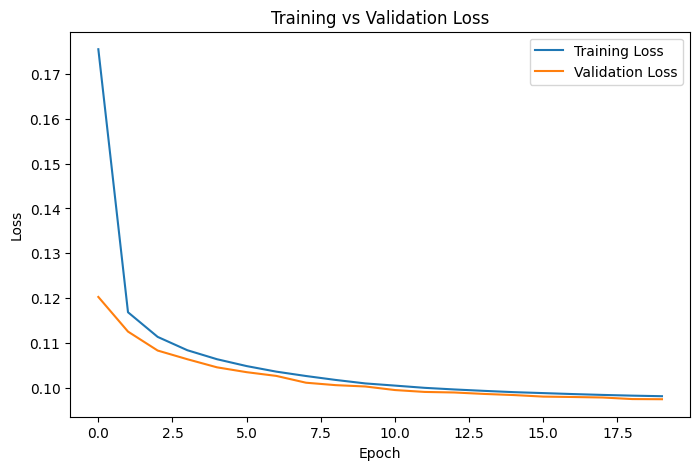

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [12]:
# Generate denoised images

decoded_imgs = autoencoder.predict(x_test_noisy)

print("Denoised images generated successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Denoised images generated successfully!


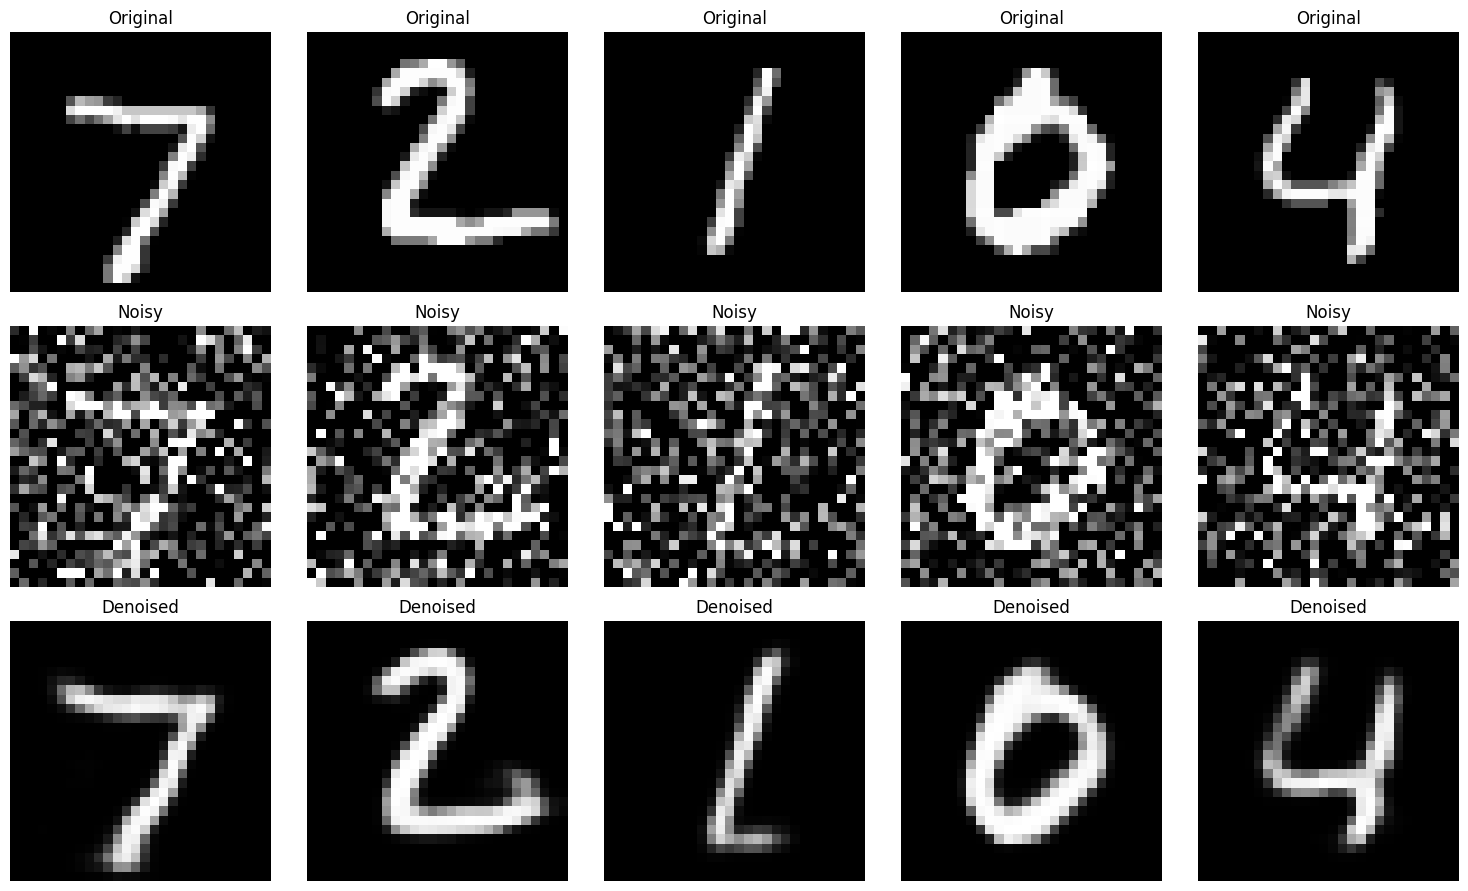

In [13]:
n = 5

plt.figure(figsize=(15,9))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Results

- Successfully loaded and preprocessed the MNIST dataset.
- Added Gaussian noise to handwritten digit images.
- Built and trained a Convolutional Autoencoder.
- Training loss decreased from **0.1755** to **0.0981**.
- Validation loss decreased from **0.1203** to **0.0974**.
- The model effectively reconstructed cleaner images from noisy inputs.

# Conclusion

In this project, a Convolutional Autoencoder was developed to remove noise from handwritten digit images using the MNIST dataset.

The model successfully learned compressed feature representations through the encoder and reconstructed cleaner images using the decoder.

Gaussian noise was added to the original images, and the trained autoencoder effectively restored the important digit structures while reducing unwanted noise.

The decreasing training and validation loss demonstrated that the model learned meaningful image representations without significant overfitting.

Overall, this project illustrates the effectiveness of autoencoders for image denoising and image reconstruction tasks in deep learning.